# Beamformers demo with towed array

This notebook demonstrates the use of the Delay-and-Sum and Minimum Variance Distortionless Response (MVDR) beamformers on simulated data from a towed array platform. The setup is as usual then each beamformer is applied to the simulated data and the results visualized.

In [1]:
import numpy as np

np.random.seed(1999)

from datetime import datetime, timedelta

import numpy as np
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
)

SIM_PARAMS = {
    "start_time": datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval": timedelta(seconds=10),
    "num_steps": 180,
}

SHIP_PARAMS = {
    "start_vector": np.array([0, 0, 0, 0, -10.0, 0]),  # stationary ship
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 256,
    "tow_cable_length": 800.0,
    "sensor_spacing": 1.0,
    "array_depth": -200.0,
}

In [3]:
from stonesoup.types.groundtruth import GroundTruthState

from nereus.platform import TowedArrayPlatform

initial_state = GroundTruthState(SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"])

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_models=[SHIP_PARAMS["transition_model"]],
    transition_times=[
        timedelta(seconds=SIM_PARAMS["time_interval"].total_seconds() * SIM_PARAMS["num_steps"])
    ],
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)


from stonesoup.types.groundtruth import GroundTruthPath, GroundTruthState

TARGET_PARAMS = {
    "start_vector": np.array([-10000, 10, 5000, 0, -10.0, 0]),  # 20 knots = 10.29 m/s
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0.001), ConstantVelocity(0.001), ConstantVelocity(0)]
    ),
    "amplitudes_upa": 10 ** (np.array([95.0, 102.0, 98.0]) / 20),
    "frequencies_hz": np.array([60.0, 120.0, 85.0]),
    "phases_rad": np.random.uniform(0, 2 * np.pi, 3),
}

# Create initial state with acoustic metadata
target_states = [
    GroundTruthState(
        TARGET_PARAMS["start_vector"],
        timestamp=SIM_PARAMS["start_time"],
        metadata={
            "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
            "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
            "phases_rad": TARGET_PARAMS["phases_rad"],
            "position_mapping": TARGET_PARAMS["position_mapping"],
            "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
        },
    )
]

# Generate trajectory using transition model
transition_model = TARGET_PARAMS["transition_model"]
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    time_interval = new_time - target_states[-1].timestamp

    # Apply transition model to get new state
    new_state_vector = transition_model.function(
        target_states[-1], noise=True, time_interval=time_interval
    )

    new_state = GroundTruthState(
        new_state_vector,
        timestamp=new_time,
        metadata={
            "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
            "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
            "phases_rad": TARGET_PARAMS["phases_rad"],
            "position_mapping": TARGET_PARAMS["position_mapping"],
            "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
        },
    )
    target_states.append(new_state)

# Create ground truth path object
target_ground_truth = GroundTruthPath(target_states)

from nereus.plotter import BearingsPlotter

# Store ground truth relative bearings at each time step
# Bearings are relative to the platform's heading
gt_relative_bearings = []

for target_state in target_ground_truth.states:
    # Get the platform state at the corresponding timestamp
    platform_state = platform.get_platform_state_at(target_state.timestamp)

    ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)

    # Extract target position (x, y) from state vector [x, vx, y, vy, z, vz]
    target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])

    # Calculate relative position from the true acoustic center to the target
    relative_pos = target_pos - ref_sensor_position[:2]  # Use only x, y from the center

    # Convert to bearing (angle from positive x-axis, measured counter-clockwise)
    bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])
    gt_relative_bearings.append(bearing_rad)

# Convert to numpy arrays for easier manipulation
gt_relative_bearings = np.array(gt_relative_bearings)

# Create GroundTruthPath from the bearing measurements
relative_bearing_truth_states = []
for i, bearing in enumerate(gt_relative_bearings):
    timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    # Create a state vector with just the bearing (no bearing rate for now)
    bearing_state = GroundTruthState(state_vector=np.array([bearing]), timestamp=timestamp)
    relative_bearing_truth_states.append(bearing_state)

# Create the GroundTruthPath object
relative_bearing_ground_truth = GroundTruthPath(relative_bearing_truth_states)

timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]

style_guide = {"figure": {"figsize": (4, 4), "font_size": 10}}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

/home/fin/miniconda3/envs/nereus-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Signal simulation

Here the two beamformers are defined and applied to simulated data from a towed array platform.


Running simulation with DelayAndSumBeamformer...

Data generation took 12.38 seconds.

Running simulation with MinimumVarianceDistortionlessResponseBeamformer...

Data generation took 57.84 seconds.


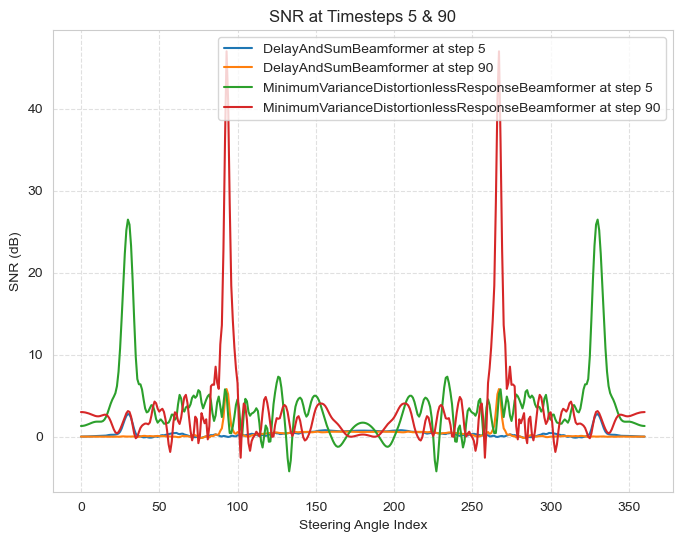

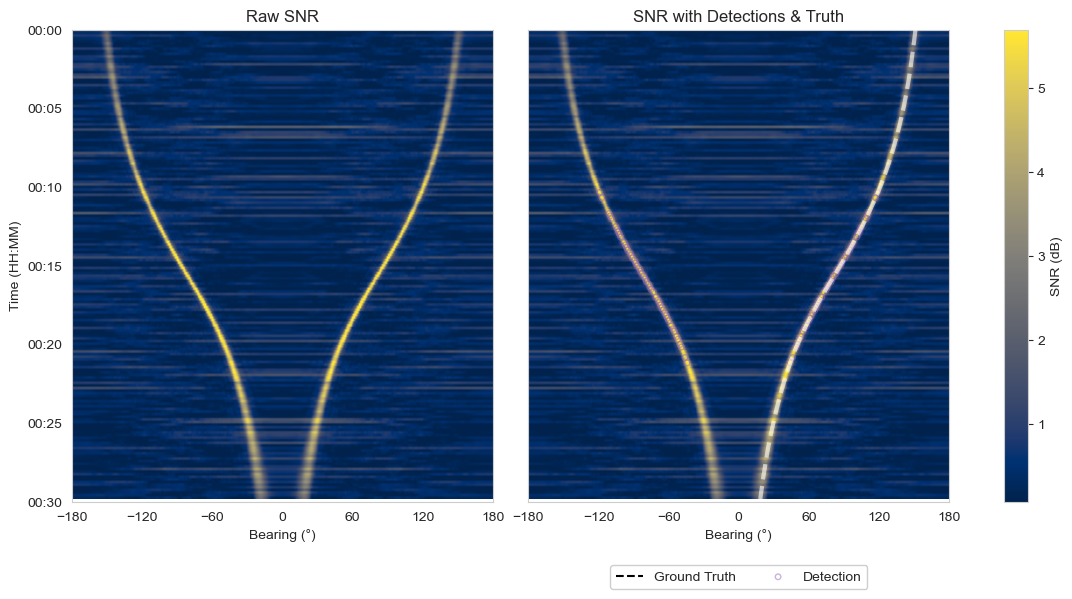

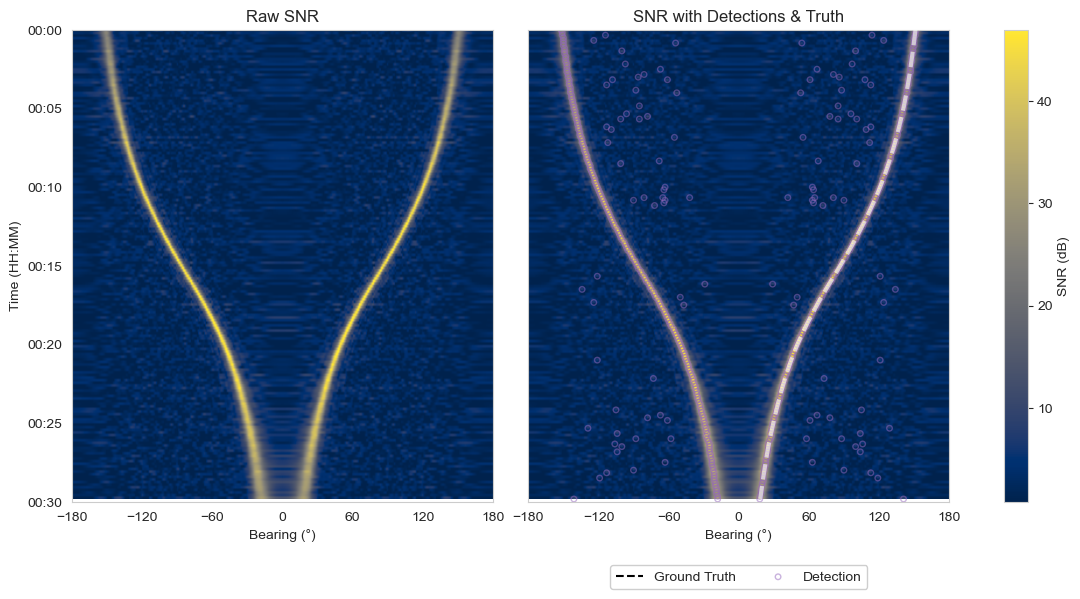

In [4]:
from scipy.signal import get_window

from nereus.detector import CFARDetector, PassiveSonarDetector, PeakDetector
from nereus.models.environment import Munk
from nereus.models.propagation import CylindricalAcousticPropagationModel
from nereus.signal.anthropogenic import TonalSignal
from nereus.signal.ambient import ColouredNoise
from nereus.sigproc import (
    DelayAndSumBeamformer,
    MinimumVarianceDistortionlessResponseBeamformer,
    SteeringCalculator,
)
from nereus.simulator import PassiveSonarArraySimulator
from time import time

PROP_PARAMS = {"ssp": Munk()}

SIGNAL_PARAMS = {
    "duration_s": 1.0,
    "sampling_rate_hz": 500.0,
    "noise_amplitude_upa": 10 ** (85 / 20),  # 90 dB noise level
    "noise_spectral_exponent": -1,  # -1 for pink noise
}

BF_PARAMS = {
    "shading": "blackman",
    "domain": "frequency",
}

STEER_PARAMS = {
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 361),
}

DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 2,
        "num_training_cells": 10,
        "threshold_factor": 3.0,
    },
    "peak_detector": {"distance": 3},
}

propagation_model = CylindricalAcousticPropagationModel(ssp=PROP_PARAMS["ssp"])

signal_model = TonalSignal(
    duration_s=SIGNAL_PARAMS["duration_s"], sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"]
)

noise_model = ColouredNoise(
    amplitude_upa=SIGNAL_PARAMS["noise_amplitude_upa"],
    spectral_exponent=SIGNAL_PARAMS["noise_spectral_exponent"],
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

das_beamformer = DelayAndSumBeamformer(
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    # shading=get_window(BF_PARAMS["shading"], platform.num_sensors),
    shading=None,
    domain=BF_PARAMS["domain"],
)

# MVDR beamformer with frequency limits (competitive speed with DaS, better SNR too)
mvdr_beamformer = MinimumVarianceDistortionlessResponseBeamformer(
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"], fmin=55.0, fmax=125.0
)


steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=STEER_PARAMS["steering_azimuths_rad"],
)

beamformers = [das_beamformer, mvdr_beamformer]

import matplotlib.pyplot as plt
from nereus.plotter import BearingsPlotter

powerfig, powerax = plt.subplots(figsize=(8, 6))
for beamformer in beamformers:
    print(f"\nRunning simulation with {beamformer.__class__.__name__}...\n")
    time_start = time()

    simulator = PassiveSonarArraySimulator(
        platform=platform,
        propagation_model=propagation_model,
        signal_model=signal_model,
        noise_model=noise_model,
        beamformer=beamformer,
        steering_calculator=steering_calculator,
        ground_truth_paths=[target_ground_truth],
    )

    data_generator = simulator.sensor_data_gen()

    cfar_detector = CFARDetector(
        num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
        num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
        threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
    )
    peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])

    detection_chain = [cfar_detector, peak_detector]

    detector = PassiveSonarDetector(
        detection_chain=detection_chain,
        sensor_data_gen=data_generator,
        steering_azimuths_rad=STEER_PARAMS["steering_azimuths_rad"],
    )

    all_detections = list(detector.detections_gen())
    snr_map = detector.snr_history

    time_end = time()
    print(f"Data generation took {time_end - time_start:.2f} seconds.")

    detections_for_plotter = [detection_set for _, detection_set in all_detections]

    timesteps = [
        SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        for i in range(SIM_PARAMS["num_steps"])
    ]

    # Create the figure and subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True, tight_layout=True)

    # Instantiate the plotter
    style_guide = {"figure": {"figsize": (4, 4), "font_size": 10}}
    plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

    # --- Left Plot: Raw SNR ---
    plotter.plot_snr(
        snr_array=snr_map,
        timesteps=timesteps,
        all_detections=[],
        truths=[],
        ax=axs[0],
        add_colorbar=False,
    )

    # --- Right Plot: SNR with Detections & Truth ---
    _, im = plotter.plot_snr(
        snr_array=snr_map,
        timesteps=timesteps,
        all_detections=detections_for_plotter,
        truths=[relative_bearing_ground_truth],
        ax=axs[1],
        add_colorbar=False,  # We will add the colorbar manually below
    )
    axs[1].set_ylabel("")  # Remove the duplicate y-axis label

    # --- Add a single, shared colorbar ---
    fig.colorbar(im, ax=axs.tolist(), label="SNR (dB)")

    # Add subplot titles
    axs[0].set_title("Raw SNR")
    axs[1].set_title("SNR with Detections & Truth")

    # single timestep snr plot
    time_step_plot_1 = 5
    time_step_plot_2 = len(timesteps) // 2
    powerax.set_title(f"SNR at Timesteps {time_step_plot_1} & {time_step_plot_2}")
    powerax.plot(
        snr_map[time_step_plot_1, :],
        label=f"{beamformer.__class__.__name__} at step {time_step_plot_1}",
    )
    powerax.plot(
        snr_map[time_step_plot_2, :],
        label=f"{beamformer.__class__.__name__} at step {time_step_plot_2}",
    )
    powerax.legend()
    powerax.set_xlabel("Steering Angle Index")
    powerax.set_ylabel("SNR (dB)")

plt.show()